# LSTM Based Sentiment Analysis using IMDB Movie Reviews

**Student:** Rohith John  
**Roll No:** 24BAD100

# PART A: DATASET PREPARATION AND TEXT PREPROCESSING

In [9]:
# Import libraries

import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## Dataset Loading

In [10]:
# Find IMDB_Dataset.csv inside Kaggle Input

csv_files = []

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.lower() == "imdb_dataset.csv":
            csv_files.append(os.path.join(root, file))

if not csv_files:
    raise FileNotFoundError(
        "IMDB_Dataset.csv was not found. Attach the IMDB dataset from "
        "the Kaggle Input panel and run this cell again."
    )

print("IMDB dataset found at:")
for path in csv_files:
    print(path)

DATASET_PATH = csv_files[0]

df = pd.read_csv(DATASET_PATH)

print("\nDataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

display(df.head())


IMDB dataset found at:
/kaggle/input/datasets/rehanliaqat17/imbd-dataset/IMDB_Dataset.csv

Dataset loaded successfully!
Shape: (50000, 2)
Columns: ['review', 'sentiment']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Dataset Exploration

In [11]:
# Dataset information

print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())


Dataset shape: (50000, 2)

Missing values:
review       0
sentiment    0
dtype: int64

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [12]:
# Sample positive and negative reviews

positive_review = df[df["sentiment"].str.lower() == "positive"]["review"].iloc[0]
negative_review = df[df["sentiment"].str.lower() == "negative"]["review"].iloc[0]

print("----- POSITIVE REVIEW -----\n")
print(positive_review[:1200])

print("\n\n----- NEGATIVE REVIEW -----\n")
print(negative_review[:1200])


----- POSITIVE REVIEW -----

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal 

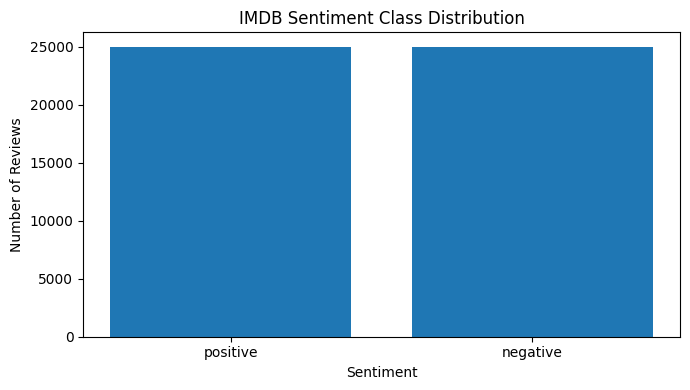

In [13]:
# Sentiment class distribution

class_counts = df["sentiment"].str.lower().value_counts()

plt.figure(figsize=(7, 4))
plt.bar(class_counts.index, class_counts.values)
plt.title("IMDB Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()


## Label Encoding and Dataset Split

In [14]:
# Convert labels to numerical form

df["label"] = df["sentiment"].str.lower().map({
    "negative": 0,
    "positive": 1
})

print(df[["sentiment", "label"]].head())
print("\nLabel counts:")
print(df["label"].value_counts())


  sentiment  label
0  positive      1
1  positive      1
2  positive      1
3  negative      0
4  positive      1

Label counts:
label
1    25000
0    25000
Name: count, dtype: int64


In [15]:
# 80% training, 10% validation, 10% testing

texts = df["review"].values
labels = df["label"].values.astype(np.float32)

X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    texts,
    labels,
    test_size=0.20,
    random_state=SEED,
    stratify=labels
)

X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training samples  :", len(X_train_text))
print("Validation samples:", len(X_val_text))
print("Testing samples   :", len(X_test_text))


Training samples  : 40000
Validation samples: 5000
Testing samples   : 5000


## Text Preprocessing

In [16]:
# Text preprocessing

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

X_train_clean = [clean_text(text) for text in X_train_text]
X_val_clean = [clean_text(text) for text in X_val_text]
X_test_clean = [clean_text(text) for text in X_test_text]

print("Original review:")
print(X_train_text[0][:500])

print("\nPreprocessed review:")
print(X_train_clean[0][:500])


Original review:
I caught this little gem totally by accident back in 1980 or '81. I was at a revival theatre to see two old silly sci-fi movies. The theatre was packed full and (with no warning) they showed a bunch of sci-fi short spoofs (to get us in the mood). Most were somewhat amusing but THIS came on and, within seconds, the audience was in hysterics! The biggest laugh came when they showed "Princess Laia" having huge cinnamon buns instead of hair on her head. She looks at the camera, gives a grim smile an

Preprocessed review:
i caught this little gem totally by accident back in or i was at a revival theatre to see two old silly sci fi movies the theatre was packed full and with no warning they showed a bunch of sci fi short spoofs to get us in the mood most were somewhat amusing but this came on and within seconds the audience was in hysterics the biggest laugh came when they showed princess laia having huge cinnamon buns instead of hair on her head she looks at the camera give

## Tokenization

In [17]:
# Tokenization and vocabulary creation

MAX_VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 200
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    oov_token=OOV_TOKEN
)

tokenizer.fit_on_texts(X_train_clean)

word_index = tokenizer.word_index

print("Vocabulary size:", len(word_index))
print("Maximum vocabulary used:", MAX_VOCAB_SIZE)

print("\nFirst 20 vocabulary entries:")
print(list(word_index.items())[:20])


Vocabulary size: 90522
Maximum vocabulary used: 20000

First 20 vocabulary entries:
[('<OOV>', 1), ('the', 2), ('and', 3), ('a', 4), ('of', 5), ('to', 6), ('is', 7), ('it', 8), ('in', 9), ('i', 10), ('this', 11), ('that', 12), ('s', 13), ('was', 14), ('as', 15), ('movie', 16), ('for', 17), ('with', 18), ('but', 19), ('film', 20)]


In [18]:
# Convert text into numerical sequences

X_train_seq = tokenizer.texts_to_sequences(X_train_clean)
X_val_seq = tokenizer.texts_to_sequences(X_val_clean)
X_test_seq = tokenizer.texts_to_sequences(X_test_clean)

print("Example sequence:")
print(X_train_seq[0][:30])

print("\nOriginal token count:", len(X_train_seq[0]))


Example sequence:
[10, 1031, 11, 121, 1480, 453, 34, 1592, 145, 9, 41, 10, 14, 32, 4, 8622, 1636, 6, 66, 107, 159, 660, 854, 847, 98, 2, 1636, 14, 2801, 357]

Original token count: 164


## Sequence Padding

In [19]:
# Pad sequences to equal length

X_train = pad_sequences(
    X_train_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_val = pad_sequences(
    X_val_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

print("X_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)
print("X_test shape :", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_val shape  :", y_val.shape)
print("y_test shape :", y_test.shape)


X_train shape: (40000, 200)
X_val shape  : (5000, 200)
X_test shape : (5000, 200)

y_train shape: (40000,)
y_val shape  : (5000,)
y_test shape : (5000,)


In [20]:
# Part A summary

VOCAB_SIZE = min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1)

print("===== PART A SUMMARY =====")
print("Vocabulary size     :", VOCAB_SIZE)
print("Sequence length     :", MAX_SEQUENCE_LENGTH)
print("Training samples    :", X_train.shape[0])
print("Validation samples  :", X_val.shape[0])
print("Testing samples     :", X_test.shape[0])
print("Negative label      : 0")
print("Positive label      : 1")


===== PART A SUMMARY =====
Vocabulary size     : 20000
Sequence length     : 200
Training samples    : 40000
Validation samples  : 5000
Testing samples     : 5000
Negative label      : 0
Positive label      : 1


# PART B: EMBEDDING GENERATION

## Embedding Layer

In [21]:
# Define embedding parameters

EMBEDDING_DIM = 64

embedding_layer = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    mask_zero=True,
    name="word_embedding"
)

sample_batch = X_train[:4]
embedding_output = embedding_layer(sample_batch)

print("Input shape:", sample_batch.shape)
print("Embedding output shape:", embedding_output.shape)


Input shape: (4, 200)
Embedding output shape: (4, 200, 64)


2026-09-28 09:58:06.541334: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [22]:
# Inspect sample word embeddings

embedding_weights = embedding_layer.get_weights()[0]

sample_words = [
    "good",
    "great",
    "excellent",
    "bad",
    "terrible",
    "boring"
]

for word in sample_words:
    token_id = tokenizer.word_index.get(word)

    if token_id is not None and token_id < VOCAB_SIZE:
        vector = embedding_weights[token_id]
        print(f"{word:10s} -> token id: {token_id:5d}, vector shape: {vector.shape}")
    else:
        print(f"{word:10s} -> not found in configured vocabulary")


good       -> token id:    50, vector shape: (64,)
great      -> token id:    83, vector shape: (64,)
excellent  -> token id:   319, vector shape: (64,)
bad        -> token id:    75, vector shape: (64,)
terrible   -> token id:   375, vector shape: (64,)
boring     -> token id:   356, vector shape: (64,)


# PART C: IMPLEMENTING THE LSTM MODEL

## LSTM Model Architecture

In [23]:
# Build and compile the LSTM model

model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True,
        name="embedding"
    ),
    LSTM(
        64,
        return_sequences=False,
        name="lstm"
    ),
    Dropout(
        0.5,
        name="dropout"
    ),
    Dense(
        1,
        activation="sigmoid",
        name="output"
    )
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# PART D: MODEL TRAINING AND SENTIMENT PREDICTION

## Model Training

In [24]:
# Train the LSTM model

EPOCHS = 5
BATCH_SIZE = 128

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 208ms/step - accuracy: 0.7988 - loss: 0.4290 - val_accuracy: 0.8752 - val_loss: 0.3157
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 205ms/step - accuracy: 0.9007 - loss: 0.2606 - val_accuracy: 0.8802 - val_loss: 0.3254
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 211ms/step - accuracy: 0.9236 - loss: 0.2083 - val_accuracy: 0.8696 - val_loss: 0.3762


## Training Results

In [25]:
# Display training history

history_df = pd.DataFrame(history.history)

history_df.index = np.arange(1, len(history_df) + 1)
history_df.index.name = "Epoch"

display(history_df.round(4))

best_epoch = history_df["val_accuracy"].idxmax()

print("Best validation epoch:", best_epoch)
print("Best validation accuracy:",
      round(history_df.loc[best_epoch, "val_accuracy"], 4))


,accuracy,loss,val_accuracy,val_loss
Epoch,,,,
1,0.7988,0.4290,0.8752,0.3157
2,0.9007,0.2606,0.8802,0.3254
3,0.9236,0.2083,0.8696,0.3762


Best validation epoch: 2
Best validation accuracy: 0.8802


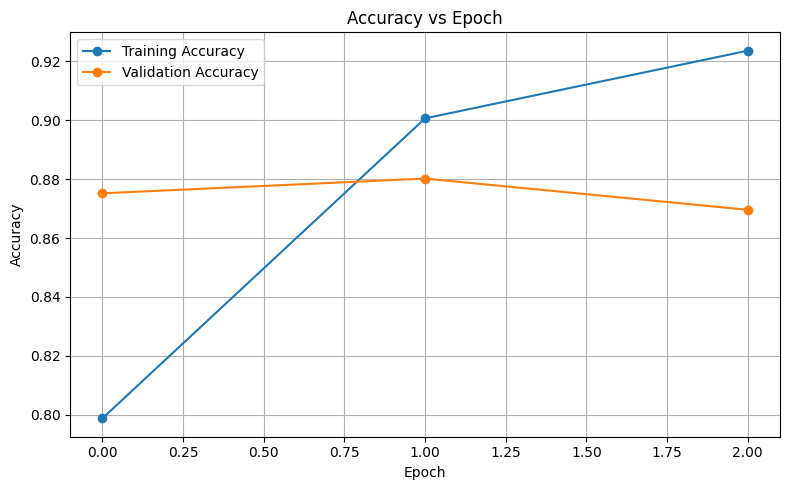

In [26]:
# Accuracy vs Epoch

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


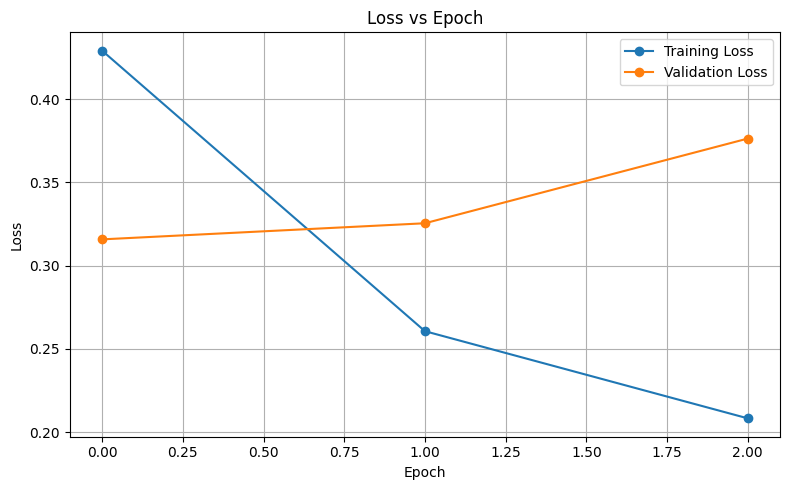

In [27]:
# Loss vs Epoch

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], marker="o", label="Training Loss")
plt.plot(history.history["val_loss"], marker="o", label="Validation Loss")
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Test Evaluation

In [28]:
# Evaluate on the test dataset

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    batch_size=BATCH_SIZE,
    verbose=1
)

print("Test Loss     :", round(test_loss, 4))
print("Test Accuracy :", round(test_accuracy, 4))


40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.8678 - loss: 0.3233
Test Loss     : 0.3233
Test Accuracy : 0.8678


In [29]:
# Generate predictions and calculate metrics

y_prob = model.predict(
    X_test,
    batch_size=BATCH_SIZE,
    verbose=1
).ravel()

y_pred = (y_prob >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("===== TEST METRICS =====")
print(f"Accuracy :  {accuracy:.4f}")
print(f"Precision:  {precision:.4f}")
print(f"Recall   :  {recall:.4f}")
print(f"F1-score :  {f1:.4f}")


40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step
===== TEST METRICS =====
Accuracy :  0.8678
Precision:  0.8786
Recall   :  0.8536
F1-score :  0.8659


## Classification Report

In [30]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"],
        digits=4
    )
)


              precision    recall  f1-score   support

    Negative     0.8576    0.8820    0.8697      2500
    Positive     0.8786    0.8536    0.8659      2500

    accuracy                         0.8678      5000
   macro avg     0.8681    0.8678    0.8678      5000
weighted avg     0.8681    0.8678    0.8678      5000



## Confusion Matrix

Confusion Matrix:
[[2205  295]
 [ 366 2134]]


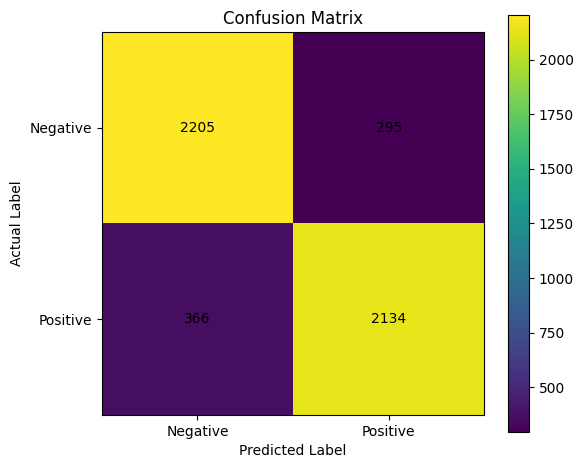

In [31]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()


## Learned Word Embeddings

In [32]:
# Inspect learned embeddings after training

learned_embeddings = model.get_layer("embedding").get_weights()[0]

for word in sample_words:
    token_id = tokenizer.word_index.get(word)

    if token_id is not None and token_id < VOCAB_SIZE:
        vector = learned_embeddings[token_id]
        print(f"{word:10s} -> vector shape: {vector.shape}")
        print("First 10 values:", np.round(vector[:10], 4))
        print()


good       -> vector shape: (64,)
First 10 values: [ 0.0653 -0.0691  0.0117  0.0542 -0.0039  0.0724 -0.0399 -0.0233 -0.0387
  0.0153]

great      -> vector shape: (64,)
First 10 values: [ 0.0933 -0.1173 -0.049   0.0863  0.0523  0.1056 -0.1412 -0.0976 -0.134
  0.0908]

excellent  -> vector shape: (64,)
First 10 values: [ 0.0626 -0.0991 -0.0553  0.1028  0.0128  0.1487 -0.0826 -0.0979 -0.1586
  0.1094]

bad        -> vector shape: (64,)
First 10 values: [-0.083   0.1299  0.0305 -0.076  -0.0174 -0.0904  0.1282  0.1004  0.1827
 -0.0833]

terrible   -> vector shape: (64,)
First 10 values: [-0.1334  0.1387 -0.0034 -0.1814 -0.0094 -0.1561  0.1624  0.1186  0.1713
 -0.15  ]

boring     -> vector shape: (64,)
First 10 values: [-0.1218  0.1276 -0.0319 -0.1447 -0.0225 -0.1179  0.1436  0.0804  0.1436
 -0.1799]



## Sentiment Prediction for New Reviews

In [33]:
# Prediction function

def predict_sentiment(review_text):
    cleaned_text = clean_text(review_text)

    sequence = tokenizer.texts_to_sequences([cleaned_text])

    padded_sequence = pad_sequences(
        sequence,
        maxlen=MAX_SEQUENCE_LENGTH,
        padding="post",
        truncating="post"
    )

    probability = float(model.predict(padded_sequence, verbose=0)[0][0])

    sentiment = "Positive" if probability >= 0.5 else "Negative"

    return sentiment, probability


In [34]:
# Predict sample reviews

sample_reviews = [
    "The movie was absolutely fantastic and I really enjoyed every scene.",
    "The story was boring and the movie was a complete waste of time.",
    "The acting was good but the movie was too long."
]

for review in sample_reviews:
    sentiment, probability = predict_sentiment(review)

    print("Review:", review)
    print("Predicted sentiment:", sentiment)
    print("Positive probability:", round(probability, 4))
    print("-" * 80)


Review: The movie was absolutely fantastic and I really enjoyed every scene.
Predicted sentiment: Positive
Positive probability: 0.7513
--------------------------------------------------------------------------------
Review: The story was boring and the movie was a complete waste of time.
Predicted sentiment: Negative
Positive probability: 0.0472
--------------------------------------------------------------------------------
Review: The acting was good but the movie was too long.
Predicted sentiment: Positive
Positive probability: 0.5043
--------------------------------------------------------------------------------


## User Input Prediction

In [35]:
# Enter your own movie review

user_review = input("Enter a movie review: ")

sentiment, probability = predict_sentiment(user_review)

print("\nPredicted Sentiment:", sentiment)
print("Positive Probability:", round(probability, 4))
print("Negative Probability:", round(1 - probability, 4))


Enter a movie review:  movie is bad since it focused on jokes and not storyline



Predicted Sentiment: Negative
Positive Probability: 0.2206
Negative Probability: 0.7794


## Actual vs Predicted Sentiments

In [36]:
# Compare actual and predicted labels for sample test reviews

results_df = pd.DataFrame({
    "Review": X_test_text[:20],
    "Actual": np.where(y_test[:20] == 1, "Positive", "Negative"),
    "Predicted": np.where(y_pred[:20] == 1, "Positive", "Negative"),
    "Positive Probability": np.round(y_prob[:20], 4)
})

pd.set_option("display.max_colwidth", 120)
display(results_df)


,Review,Actual,Predicted,Positive Probability
0,"Although it has been 2 years, I still remember the complete waste that comprises the entire plot of the movie. Unfor...",Negative,Negative,0.0452
1,"THE BLOB is a great horror movie, not merely because of the vividly horrific images of its nearly unstoppable, flesh...",Positive,Positive,0.8757
2,The saddest thing about this film is that only 8 people cared to leave a review of it and NO-ONE felt it worthwhile ...,Positive,Positive,0.8059
3,"WARNING! This review will reveal the ending of the movie, ""Scoop."" If you don't want to know how the movie ends, don...",Negative,Negative,0.1512
4,This is a film that has garnered any interest or praise it has received simply on the merit of being a lesbian inter...,Negative,Negative,0.0813
5,"Where should I begin with this movie. All I know is that it is a mess. Be the script, story, or the actors. First of...",Negative,Negative,0.0275
6,Gene Hackman is a former Marine Corps colonel who musters a handful of private Vietnam vets to go back to Laos and r...,Negative,Negative,0.1999
7,"There are spoilers but trust me, I'm doing you a favor.<br /><br />My friends and I like to watch crappy movies ever...",Negative,Negative,0.0361
8,"This is the second Eytan Fox film I have seen. The fantastic actor, Lior Ashkenazi, who starred in Walk on Water, ha...",Positive,Positive,0.5941
9,If this movie had a point I never discovered it. A very depressing movie which supposedly is about the final evacuat...,Negative,Positive,0.9254


## Save Trained Model

In [37]:
# Save the trained model in Kaggle working directory

MODEL_PATH = "/kaggle/working/imdb_lstm_sentiment_model.keras"

model.save(MODEL_PATH)

print("Model saved to:", MODEL_PATH)


Model saved to: /kaggle/working/imdb_lstm_sentiment_model.keras
